# Prompt Guided Anomaly Detection Using MotionCLIP

In [73]:
import os
import torch
import clip
import sys
import torch.nn.functional as F
from tqdm import tqdm
from src.models.architectures.transformer import Encoder_TRANSFORMER, Decoder_TRANSFORMER
from src.models.modeltype.motionclip import MOTIONCLIP
from src.utils.get_model_and_data import get_model_and_data
from src.parser.visualize import parser
from src.utils.misc import load_model_wo_clip
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from src.utils.action_label_to_idx import action_label_to_idx
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances


In [2]:
os.environ["CLIP_CACHE_DIR"] = "D:/clip_cache"
device = "cuda" if torch.cuda.is_available() else "cpu"

### Get text embeddings of the prompt

In [3]:
def encode_text(prompt):
        clip_model, preprocess = clip.load("ViT-B/32", device=device, download_root=os.environ["CLIP_CACHE_DIR"])
        with torch.no_grad():
                tokens = clip.tokenize(prompt).to(device)

                text_embeddings = clip_model.encode_text(tokens)

                text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
        return text_embeddings, prompt

### Get MotionCLIP embeddings

In [4]:
print("Current working dir:", os.getcwd())

ckpt_path = "../classes-model/checkpoint_0200.pth.tar"

sys.argv = ["program", "--cuda", ckpt_path]
parameters, folder, checkpointname, epoch = parser(checkpoint=True)
parameters["device"] = device
parameters["dataset"] = "babel"
parameters["datapath"] = "data/amass_db/babel_30fps_db.pt" #this one has 384 unique classes
parameters["babel_dir"] = "data/babel_v1.0_release"
parameters["target_fps"] = 30
parameters['only_60_classes'] = True


assert os.path.exists("data/amass_db")

model, datasets = get_model_and_data(parameters, split="train")
ckpt_path = os.path.join(folder, checkpointname)
state_dict = torch.load(ckpt_path, map_location=device)
load_model_wo_clip(model, state_dict)

for p in model.parameters():
    p.requires_grad = False
model.eval()

Current working dir: d:\Delft\Uni\Thesis\MotionCLIP_experiment\MotionCLIP
datapath used by amass is [data/amass_db/babel_30fps_train.pt]
datapath used by amass is [data/amass_db/babel_30fps_train.pt]


d:\anaconda3\envs\motionclip\lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
C:\Users\meenakshi\AppData\Local\Temp\ipykernel_24456\852908339.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be a

MOTIONCLIP(
  (encoder): Encoder_TRANSFORMER(
    (skelEmbedding): Linear(in_features=150, out_features=512, bias=True)
    (sequence_pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (seqTransEncoder): TransformerEncoder(
      (layers): ModuleList(
        (0-7): 8 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (decoder): Decoder_TRANSFO

In [5]:
# for sample in datasets["train"]:
#     print(sample)

In [6]:
all_latents, all_labels = [], []
with torch.no_grad():
    for i, sample in enumerate(tqdm(datasets["train"])):
        if sample is None or "inp" not in sample:
            continue
        motion = sample["inp"].to(device).unsqueeze(0)
        label  = sample["y"]             
        T = motion.shape[-1]
        mask = torch.ones(1, T, dtype=torch.bool, device=device)
        batch = {"x": motion, "y": torch.tensor([label], dtype=torch.long, device=device), "mask": mask}

        z_out = model.encoder(batch)  
        z_p = z_out["mu"]     
        z_p = z_p / z_p.norm(dim=-1, keepdim=True)  
        all_latents.append(z_p.cpu())
        all_labels.append(label)
print(torch.unique(torch.tensor(all_labels)))


100%|██████████| 20112/20112 [07:26<00:00, 45.07it/s] 

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59])


In [7]:
print(all_labels)

[1, 1, 1, 1, 13, 13, 8, 8, 5, 5, 52, 5, 1, 1, 27, 27, 27, 33, 1, 1, 10, 10, 21, 21, 21, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 7, 1, 1, 0, 0, 0, 0, 44, 49, 49, 18, 9, 52, 7, 4, 7, 32, 32, 32, 33, 15, 14, 14, 38, 51, 2, 8, 24, 31, 31, 38, 43, 58, 59, 46, 59, 0, 22, 1, 0, 27, 48, 1, 21, 21, 13, 0, 34, 0, 0, 1, 4, 0, 0, 59, 48, 16, 24, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 0, 0, 0, 0, 34, 34, 34, 6, 0, 10, 0, 33, 0, 22, 33, 0, 0, 0, 0, 10, 21, 21, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 46, 7, 7, 4, 0, 0, 14, 0, 41, 41, 0, 41, 0, 0, 0, 0, 0, 22, 1, 1, 1, 31, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 36, 0, 1, 1, 1, 42, 1, 42, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 23, 16, 1, 1, 41, 5, 5, 41, 27, 41, 27, 8, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 21, 21, 21, 0, 0, 0, 0, 0, 3, 3, 23, 23, 1, 32, 32, 32, 32, 32, 32, 32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 34, 34, 34, 34, 0, 3, 0, 0, 0, 2, 2, 3, 3, 1, 1, 1

### Get the chosen motion embedding

In [8]:
def get_embedding_by_label(target_label):
    all_labels_tensor = torch.tensor(all_labels)
    
    indices = (all_labels_tensor == target_label).nonzero(as_tuple=True)[0]
    
    if len(indices) > 0:
        embeddings = [all_latents[i] for i in indices]
        return embeddings
    else:
        print(f"Label {target_label} not found!")
        return None

### Check for anomaly

In [9]:
# anomaly_prompts = ["Person falling", "Person stumbling while walking", "Person tripping", "Person collapsing", "Person fainting", "A person twisting their ankle", "stumble", "backwards movement", "stand"] 
anomaly_prompts = ["real fight", "punch or kick", "punch, kick or push", "punch, kick or push related to violence", "punch, kick or push related to fighting"] 

In [115]:
def check_anomaly(motion_embedding, text_embedding, threshold=0.69):
    similarity = cosine_similarity(motion_embedding.cpu().detach().numpy(), text_embedding.cpu().detach().numpy())
    # similarity = similarity[0,0]
    similarity = round(float(similarity[0,0]), 2)
    if similarity > threshold:
        return 1, similarity
        # return True, similarity  # Anomaly detected
    else:
        return 0, similarity
        # return False, similarity

# Plot t-SNE/PCA

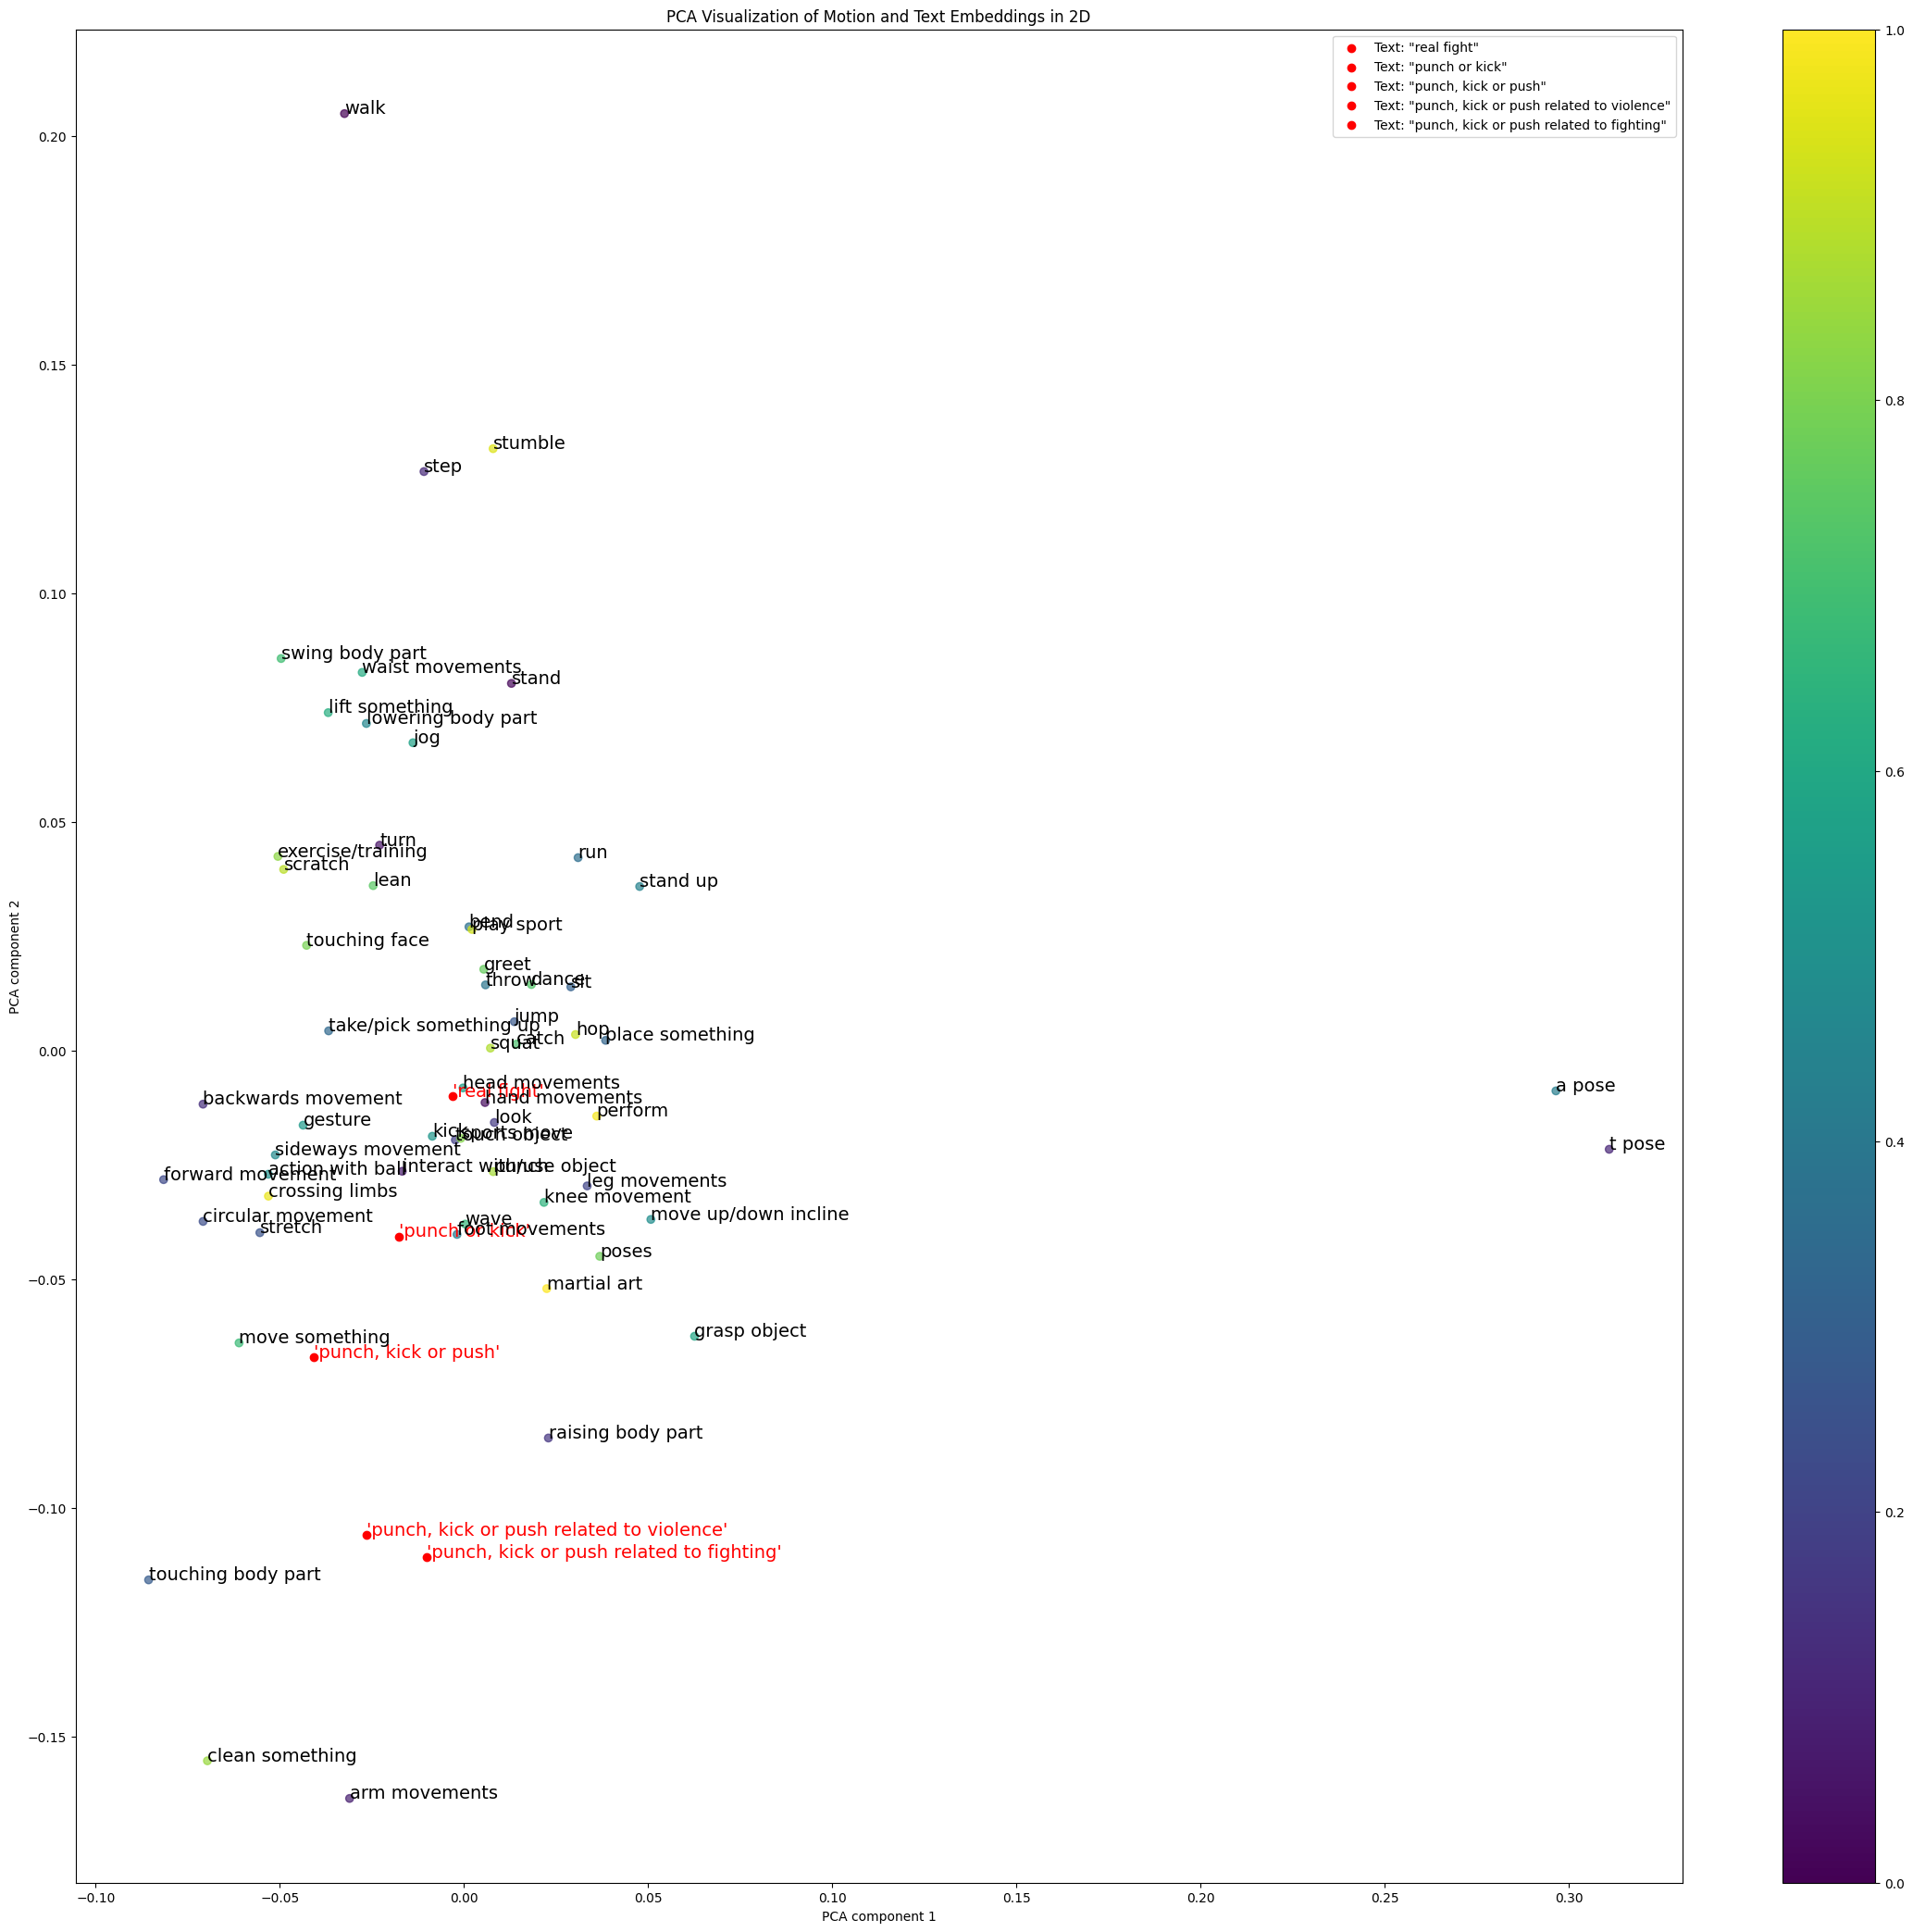

In [40]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}

first_motion_embeddings = []
first_motion_labels = []

unique_labels = np.unique(all_labels)

for label in unique_labels:
    first_index = np.where(np.array(all_labels) == label)[0][0]
    
    first_motion_embeddings.append(all_latents[first_index].cpu().detach().numpy())
    first_motion_labels.append(label)

first_motion_embeddings = np.vstack(first_motion_embeddings)

pca_motion = PCA(n_components=2) 
motion_embeddings_pca_2d = pca_motion.fit_transform(first_motion_embeddings)

text_embeddings_pca_2d = []
texts = []
texts_all = []
for prompt in anomaly_prompts:
    text_embedding, prompt = encode_text(prompt)

    text_embedding = text_embedding.cpu().detach().numpy().reshape(1, -1)  

    text_embedding_pca_2d = pca_motion.transform(text_embedding) 

    text_embeddings_pca_2d.append(text_embedding_pca_2d)
    texts.append(prompt)
plt.figure(figsize=(28, 26))

plt.scatter(motion_embeddings_pca_2d[:, 0], motion_embeddings_pca_2d[:, 1], c=first_motion_labels, cmap='viridis', alpha=0.7)

for i, text_embedding_pca in enumerate(text_embeddings_pca_2d):
    plt.scatter(text_embedding_pca[0, 0], text_embedding_pca[0, 1], c='red', label=f'Text: "{texts[i]}"')

    plt.text(text_embedding_pca[0, 0], text_embedding_pca[0, 1],
            f"'{texts[i]}'", fontsize=14, color='red')

for i, label in enumerate(first_motion_labels):
    action_label = idx_to_action_label[label] 
    plt.annotate(action_label, (motion_embeddings_pca_2d[i, 0], motion_embeddings_pca_2d[i, 1]), fontsize=14)

plt.colorbar()

plt.title("PCA Visualization of Motion and Text Embeddings in 2D")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")

plt.legend()
plt.savefig("data/graphs_anomalyDetection/anomaly_paper_prompts")
plt.show()


### Only the chosen motions

In [111]:
# chosen_labels = np.array([0,10,23,31,35,43,47,48,51,53])
chosen_labels = np.array([51,31,59,48,5,2,12,24])
#67,74,76,93,119,118

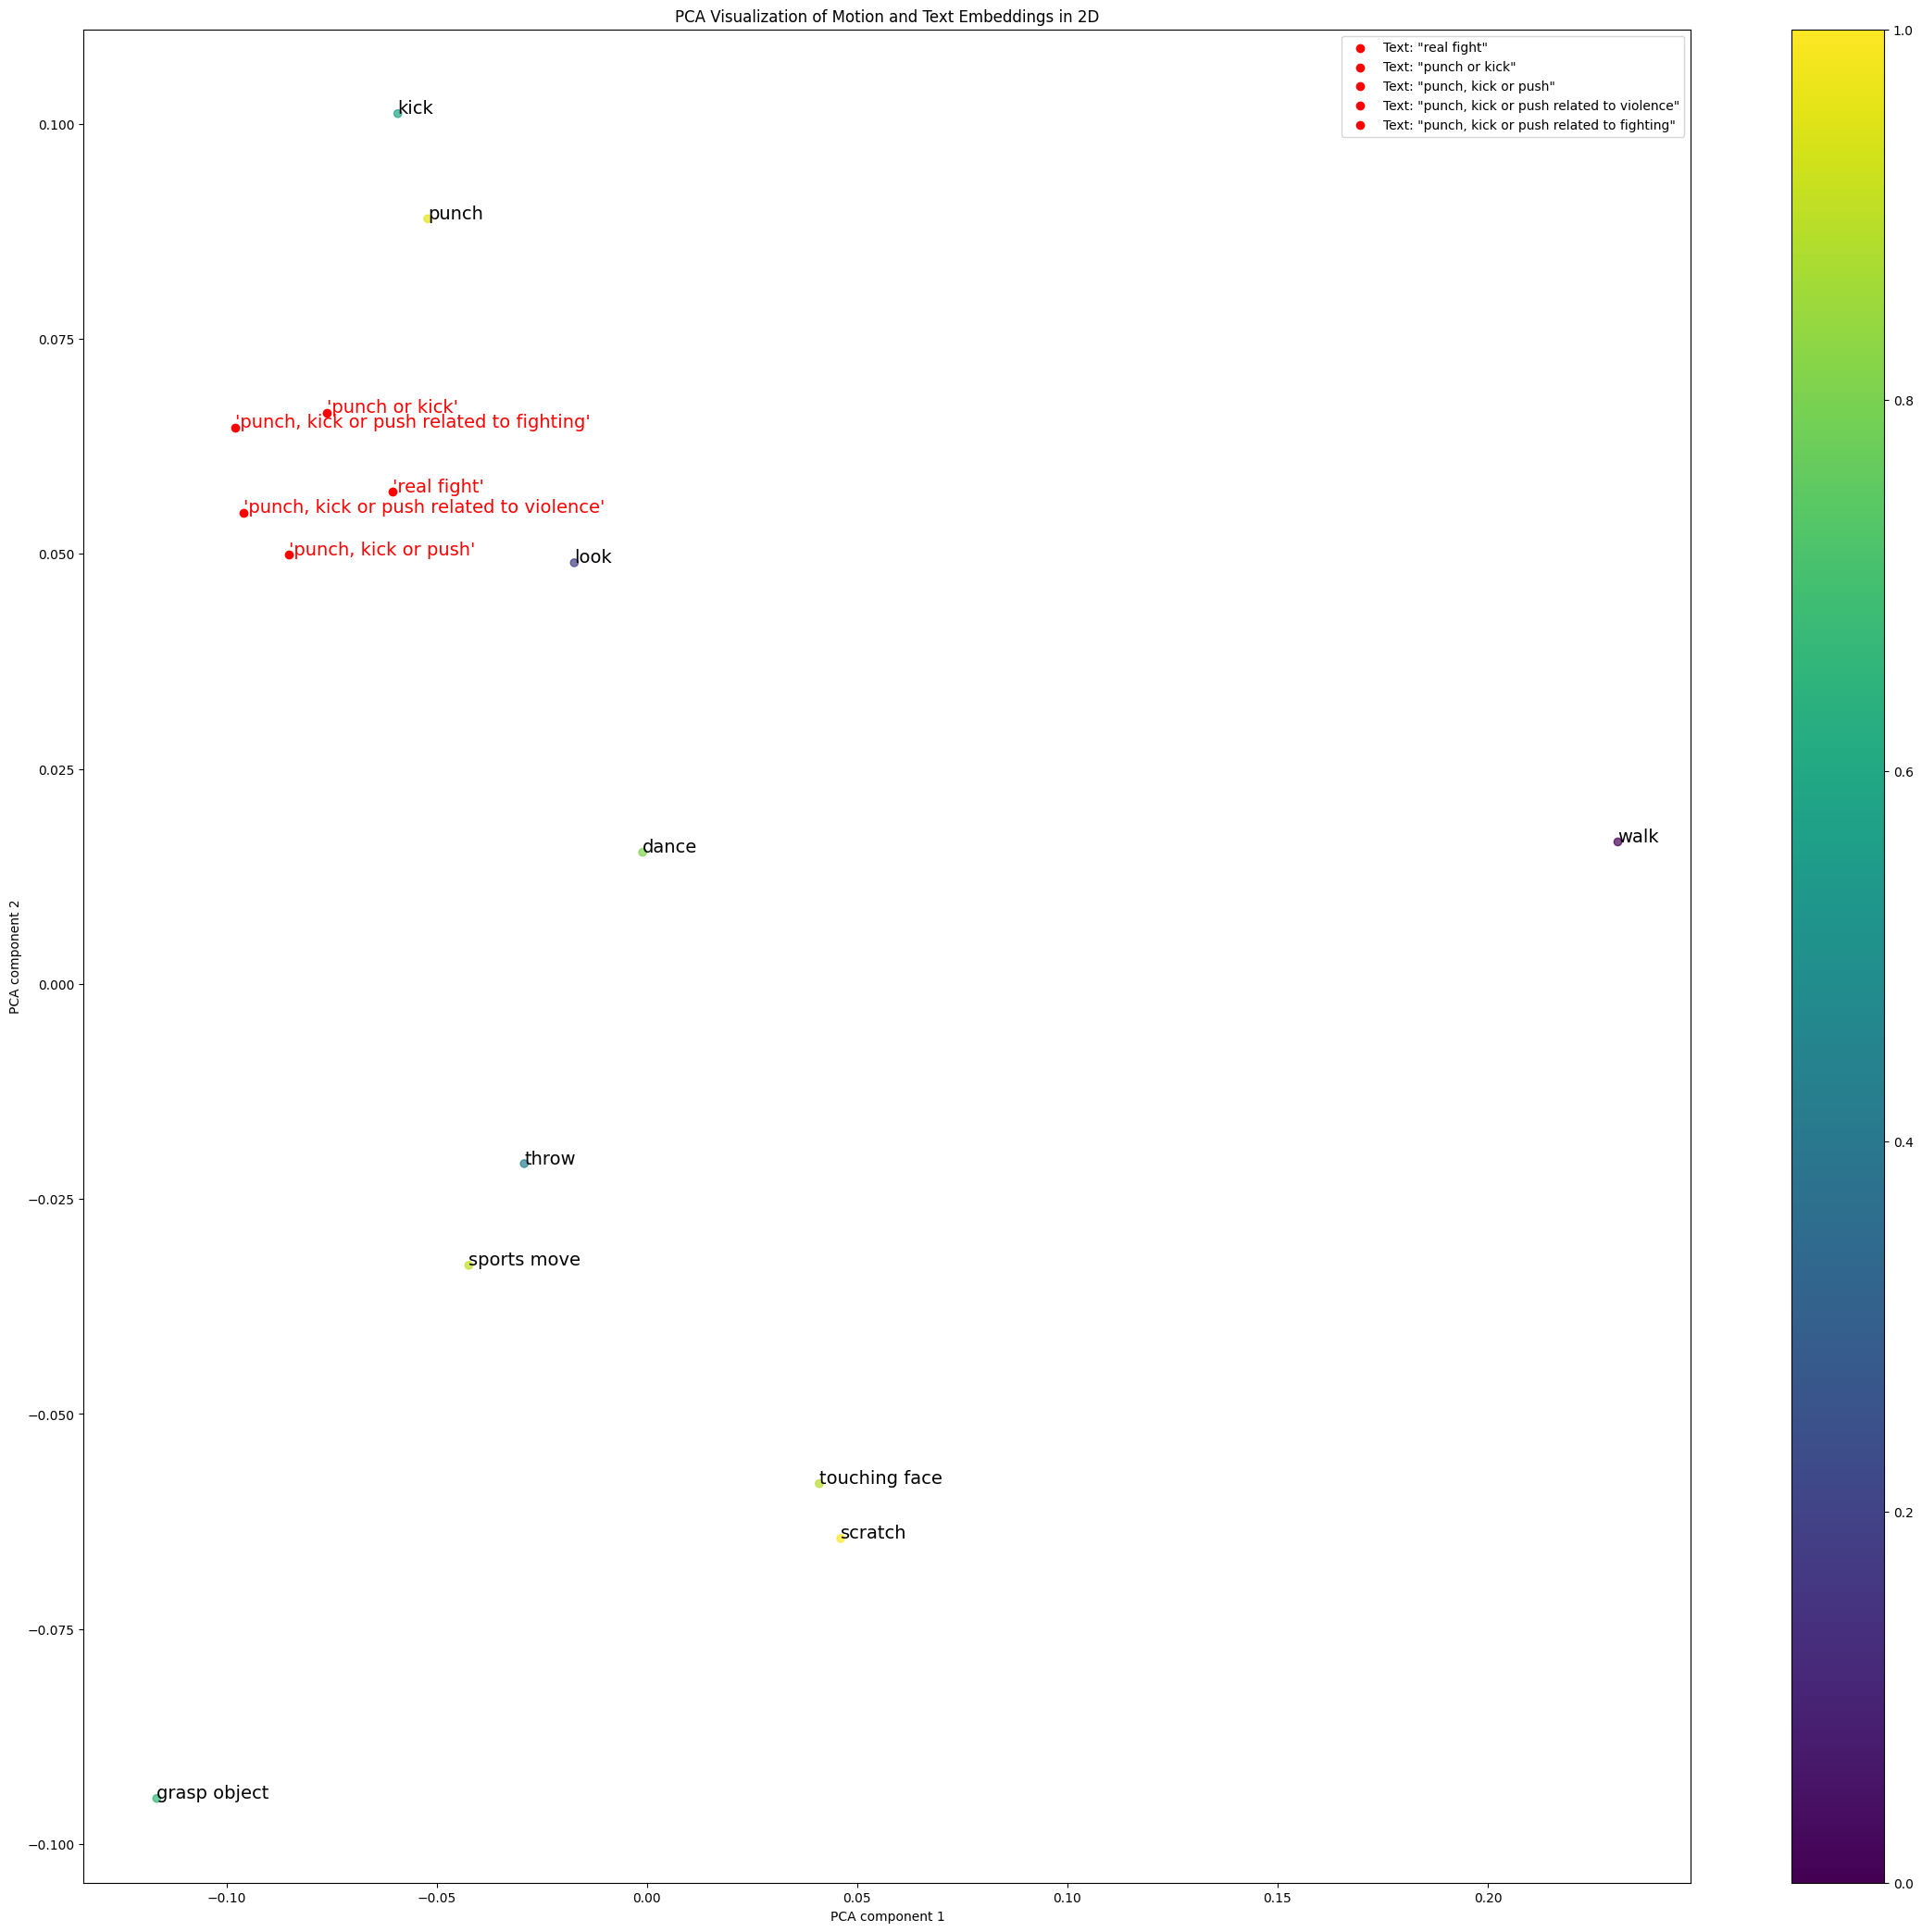

In [ ]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}

first_motion_embeddings = []
first_motion_labels = []

# unique_labels = np.unique(all_labels)
for label in chosen_labels:
    first_index = np.where(np.array(all_labels) == label)[0][0]
    
    first_motion_embeddings.append(all_latents[first_index].cpu().detach().numpy())
    first_motion_labels.append(label)

first_motion_embeddings = np.vstack(first_motion_embeddings)

pca_motion = PCA(n_components=2) 
motion_embeddings_pca_2d = pca_motion.fit_transform(first_motion_embeddings)

text_embeddings_pca_2d = []
texts = []
texts_all = []
for prompt in anomaly_prompts:
    text_embedding, prompt = encode_text(prompt)

    text_embedding = text_embedding.cpu().detach().numpy().reshape(1, -1)  

    text_embedding_pca_2d = pca_motion.transform(text_embedding) 

    text_embeddings_pca_2d.append(text_embedding_pca_2d)
    texts.append(prompt)
plt.figure(figsize=(28, 26))

plt.scatter(motion_embeddings_pca_2d[:, 0], motion_embeddings_pca_2d[:, 1], c=first_motion_labels, cmap='viridis', alpha=0.7)

for i, text_embedding_pca in enumerate(text_embeddings_pca_2d):
    plt.scatter(text_embedding_pca[0, 0], text_embedding_pca[0, 1], c='red', label=f'Text: "{texts[i]}"')

    plt.text(text_embedding_pca[0, 0], text_embedding_pca[0, 1],
            f"'{texts[i]}'", fontsize=14, color='red')

for i, label in enumerate(first_motion_labels):
    action_label = idx_to_action_label[label] 
    plt.annotate(action_label, (motion_embeddings_pca_2d[i, 0], motion_embeddings_pca_2d[i, 1]), fontsize=14)

plt.colorbar()

plt.title("PCA Visualization of Motion and Text Embeddings in 2D")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")

plt.legend()
# plt.savefig("data/graphs_anomalyDetection/anomaly_paper_prompts")
plt.show()


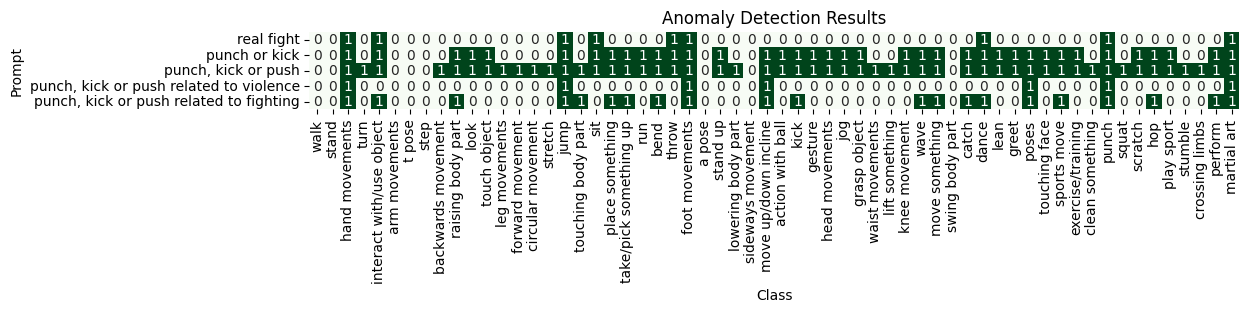

In [ ]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}

results = []

for prompt in anomaly_prompts:
    prompt_embedding, _ = encode_text(prompt)
    
    anomalies_per_prompt = []
    
    for class_id in range(0, 60):
        motion_embeddings = get_embedding_by_label(class_id)
        
        if motion_embeddings is not None:
            anomalies,_ = check_anomaly(motion_embeddings[0], prompt_embedding)
            anomalies_per_prompt.append(anomalies) 
    
    results.append(anomalies_per_prompt)

results_df = pd.DataFrame(results, columns=[idx_to_action_label[i] for i in range(60)], index=anomaly_prompts)

plt.figure(figsize=(12, 10))
sns.heatmap(results_df, annot=True, cmap="Greens", cbar=False, square=True, xticklabels=results_df.columns, yticklabels=results_df.index)
plt.title("Anomaly Detection Results")
plt.xlabel("Class")
plt.ylabel("Prompt")
# plt.savefig("data/graphs_anomalyDetection/anomaly_paper_prompts_heatmap")
plt.show()

### For the chosen classes

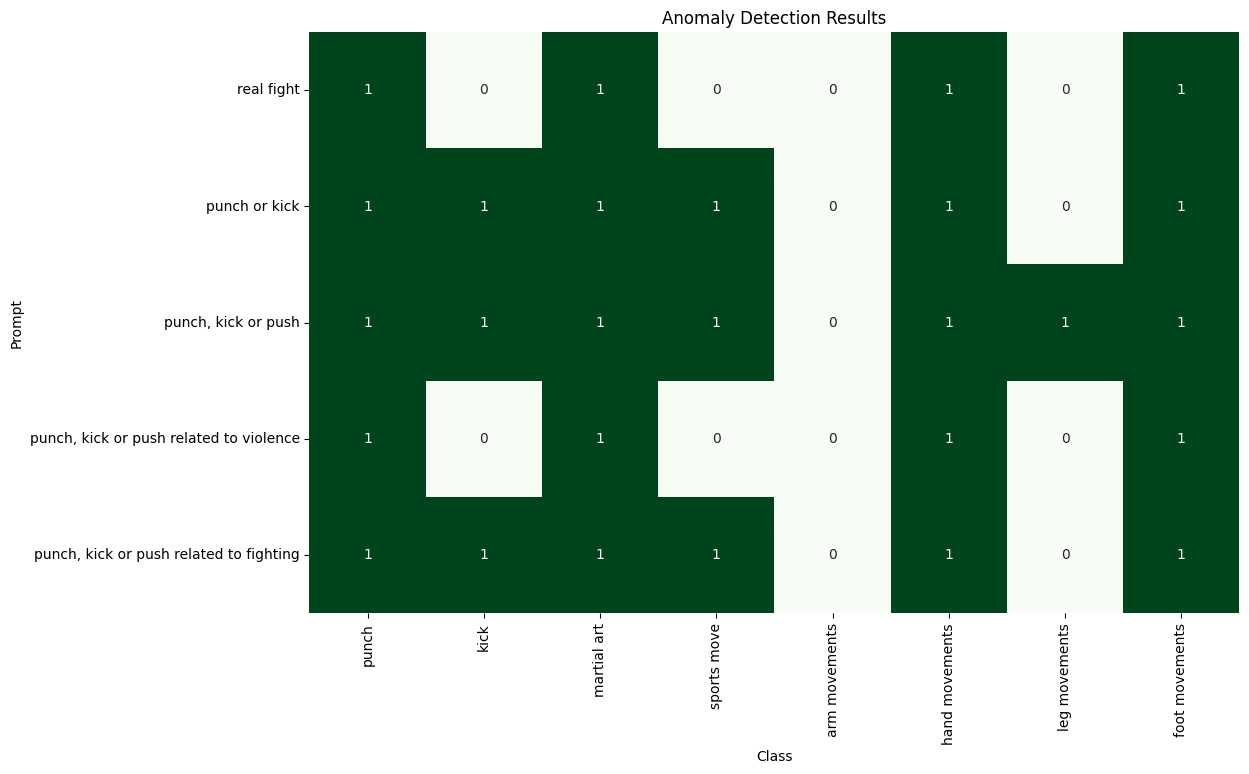

In [112]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}

results = []

for prompt in anomaly_prompts:
    prompt_embedding, _ = encode_text(prompt)
    
    anomalies_per_prompt = []
    
    for class_id in chosen_labels:
        motion_embeddings = get_embedding_by_label(class_id)
        
        if motion_embeddings is not None:
            anomalies, _ = check_anomaly(motion_embeddings[0], prompt_embedding)
            anomalies_per_prompt.append(anomalies) 
    
    results.append(anomalies_per_prompt)

results_df = pd.DataFrame(results, columns=[idx_to_action_label[i] for i in chosen_labels], index=anomaly_prompts)

plt.figure(figsize=(12, 10))
sns.heatmap(results_df, annot=True, cmap="Greens", cbar=False, square=True, xticklabels=results_df.columns, yticklabels=results_df.index)
plt.title("Anomaly Detection Results")
plt.xlabel("Class")
plt.ylabel("Prompt")
# plt.savefig("data/graphs_anomalyDetection/anomaly_paper_prompts_heatmap")
plt.show()

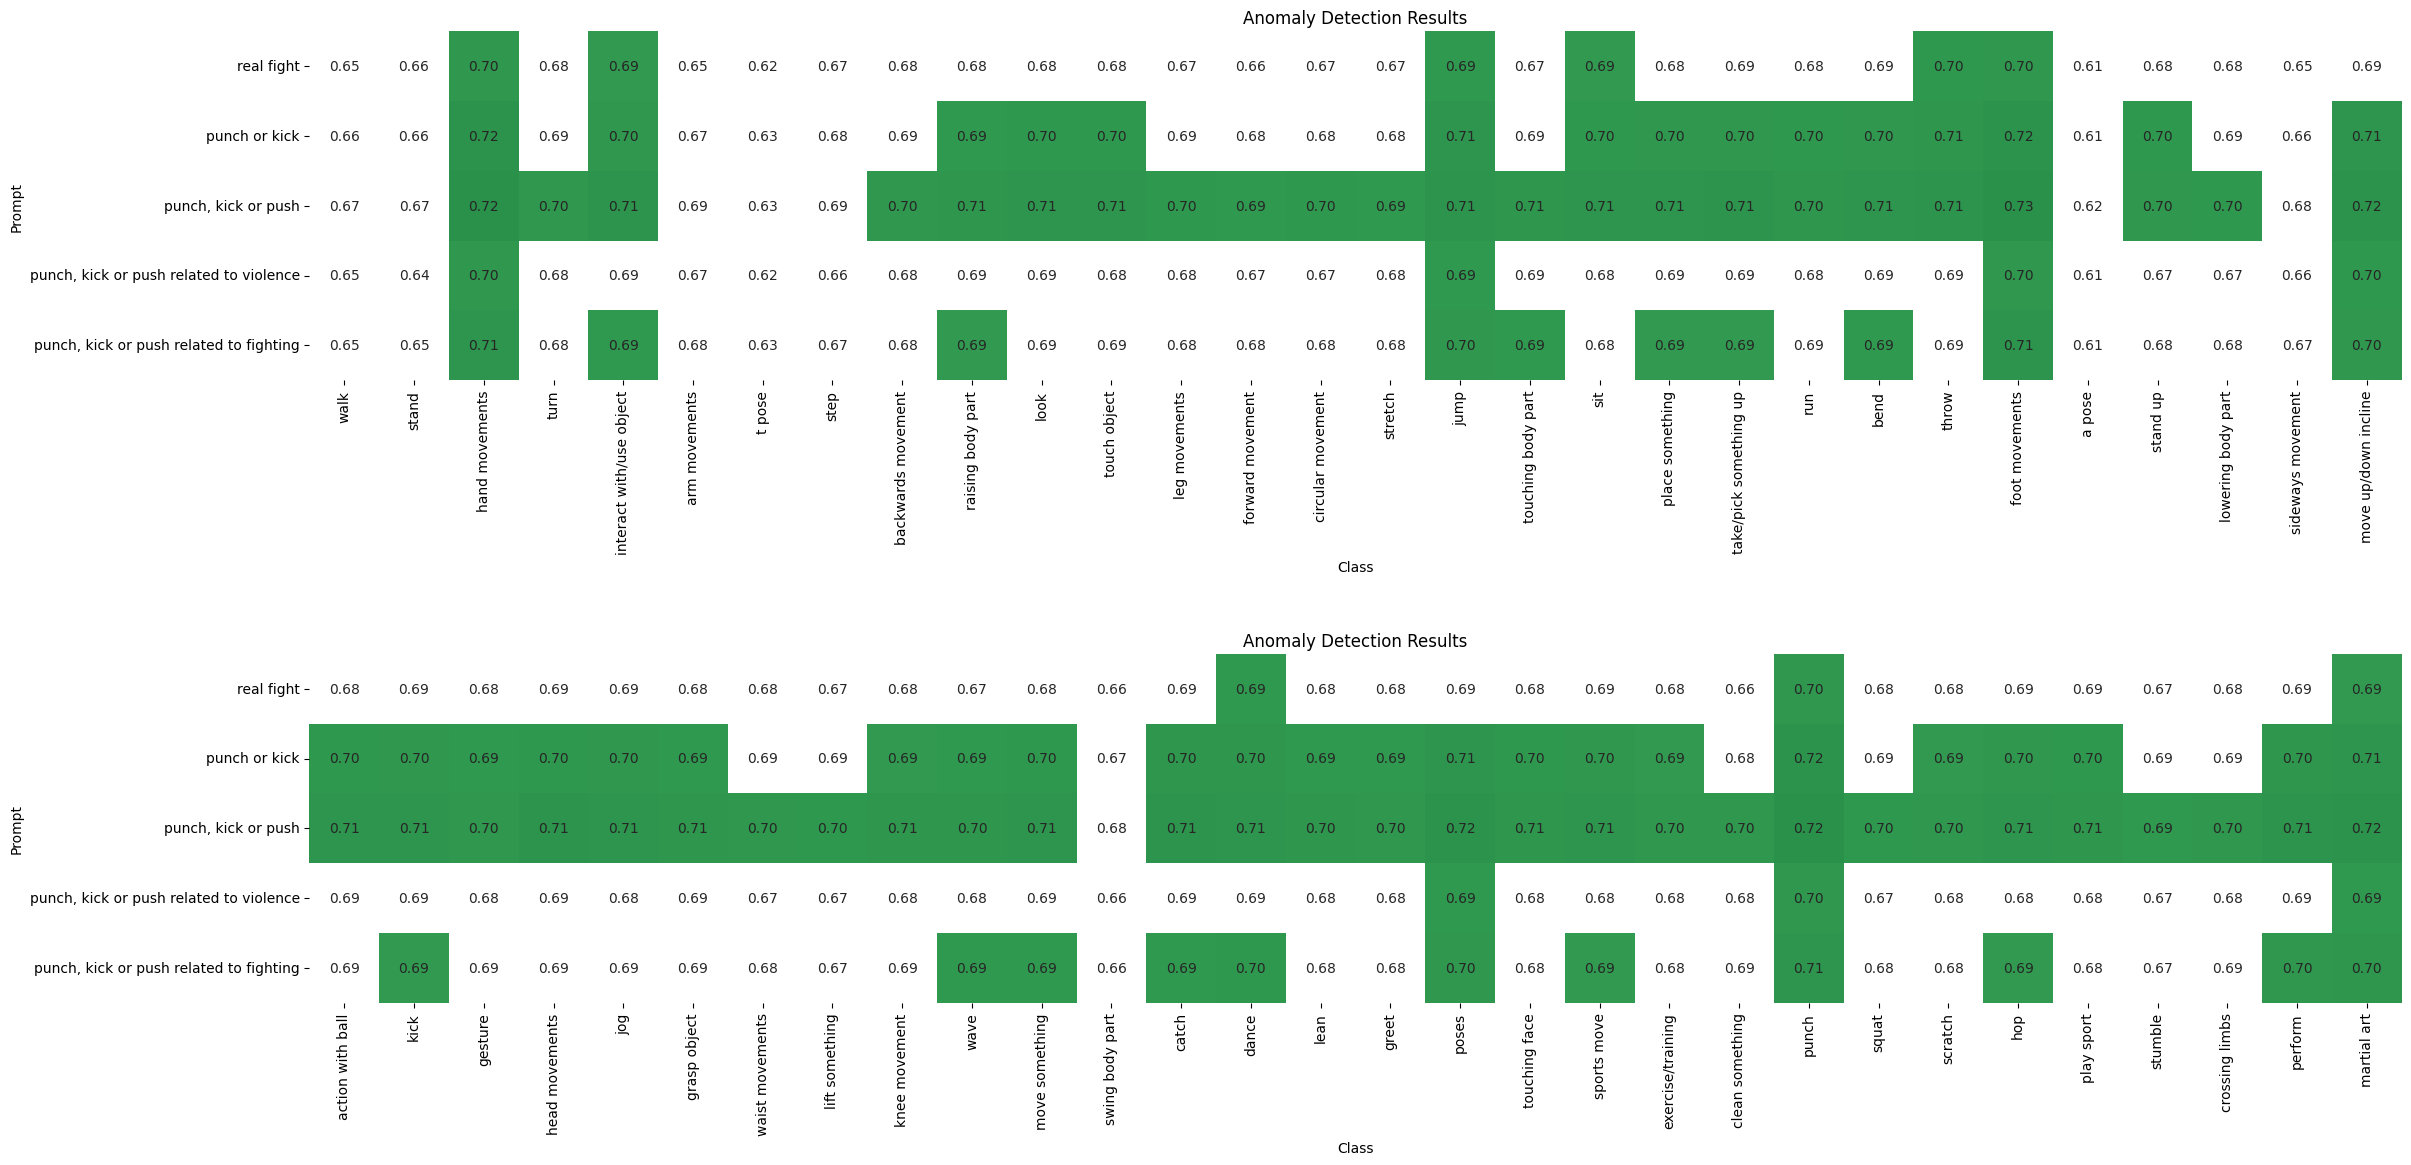

In [ ]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}
threshold = 0.69
results = []
results_flag = []
for prompt in anomaly_prompts:
    prompt_embedding, _ = encode_text(prompt)
    
    anomalies_per_prompt = []
    anomalies_flag = []

    for class_id in range(0, 60):
        motion_embeddings = get_embedding_by_label(class_id)
        
        if motion_embeddings is not None:
            anomalies, score = check_anomaly(motion_embeddings[0], prompt_embedding)
            anomalies_per_prompt.append(score) 
            anomalies_flag.append(anomalies)    
    results.append(anomalies_per_prompt)
    results_flag.append(anomalies_flag)
results_df = pd.DataFrame(results, columns=[idx_to_action_label[i] for i in range(60)], index=anomaly_prompts)
flag_df = pd.DataFrame(results_flag,columns=results_df.columns,index=results_df.index)

n_cols = results_df.shape[1]
mid = n_cols // 2

df_top  = results_df.iloc[:, :mid]
df_bottom = results_df.iloc[:, mid:]
df_top_flag = flag_df.iloc[:, :mid]
df_bot_flag = flag_df.iloc[:, mid:]


mask_top = df_top_flag == 0
mask_bot = df_bot_flag == 0


fig, axes = plt.subplots(
    2, 1,
    figsize=(24, 12),
    sharex=False,
    sharey=True,
    constrained_layout=True
)

# sns.heatmap(
#     df_top,
#     ax=axes[0],
#     cmap="Greens",
#     vmin=0.0,
#     vmax=1.0,
#     annot=True,
#     fmt=".2f",
#     cbar=True,
#     square=True
# )

sns.heatmap(
    df_top,
    ax=axes[0],
    cmap=["white"],          # solid white background
    cbar=False,
    annot=df_top.round(2),
    fmt=".2f",
    square=True
)

# overlay: show ONLY cells >= threshold in green
sns.heatmap(
    df_top,
    ax=axes[0],
    mask=mask_top,           # mask below threshold
    cmap="Greens",
    vmin=0.0,
    vmax=1.0,
    cbar=False,
    annot=False,
    square=True
)
axes[0].set_title("Anomaly Detection Results")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Prompt")

sns.heatmap(
    df_bottom,
    ax=axes[1],
    cmap=["white"],        
    cbar=False,
    annot=df_bottom.round(2),
    fmt=".2f",
    square=True
)

sns.heatmap(
    df_bottom,
    ax=axes[1],
    mask=mask_bot,           
    cmap="Greens",
    vmin=0.0,
    vmax=1.0,
    cbar=False,
    annot=False,
    square=True
)
axes[1].set_title("Classes (2)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Prompt")
# cbar = axes[1].collections[0].colorbar
# cbar.ax.axhline(threshold, color="red", linewidth=2)
# cbar.set_label("Anomaly score (cosine similarity)")
plt.title("Anomaly Detection Results")
plt.xlabel("Class")
plt.ylabel("Prompt")
# plt.savefig("data/graphs_anomalyDetection/anomaly_paper_prompts_heatmap_withScore")
plt.show()

### For the chosen classes

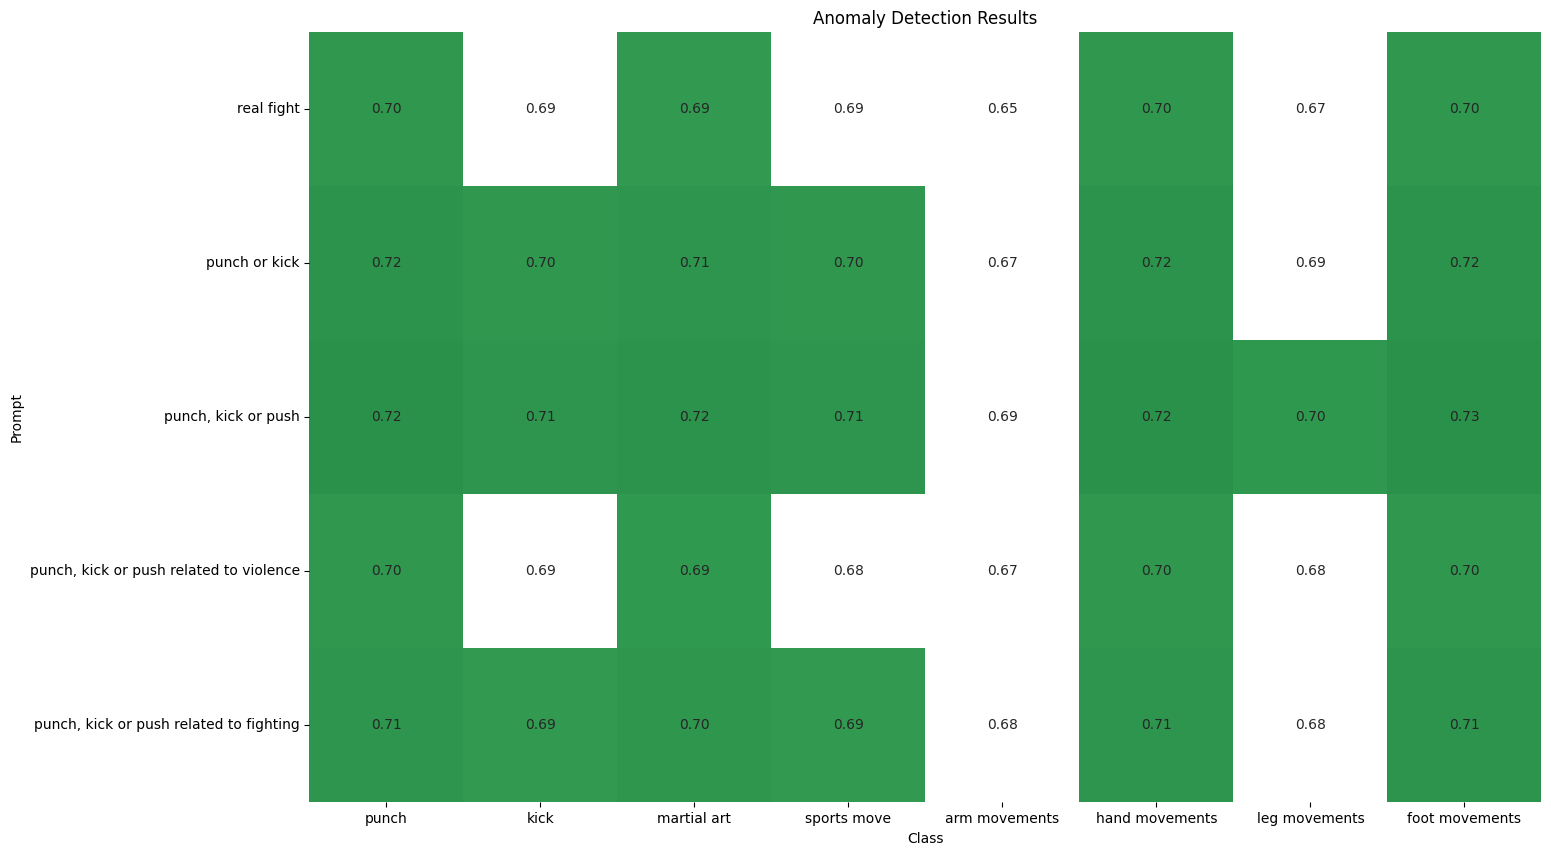

In [113]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}
threshold = 0.69
results = []
results_flag = []
for prompt in anomaly_prompts:
    prompt_embedding, _ = encode_text(prompt)
    
    anomalies_per_prompt = []
    anomalies_flag = []

    for class_id in chosen_labels:
        motion_embeddings = get_embedding_by_label(class_id)
        
        if motion_embeddings is not None:
            anomalies, score = check_anomaly(motion_embeddings[0], prompt_embedding)
            anomalies_per_prompt.append(score) 
            anomalies_flag.append(anomalies)    
    results.append(anomalies_per_prompt)
    results_flag.append(anomalies_flag)
results_df = pd.DataFrame(results, columns=[idx_to_action_label[i] for i in chosen_labels], index=anomaly_prompts)
flag_df = pd.DataFrame(results_flag,columns=results_df.columns,index=results_df.index)


mask = flag_df == 0

plt.figure(figsize=(28, 10))

sns.heatmap(
    results_df,
    cmap=["white"],
    cbar=False,
    annot=results_df.round(2),
    fmt=".2f",
    square=True
)

# overlay: only values >= threshold in green
sns.heatmap(
    results_df,
    mask=mask,          # mask below threshold
    cmap="Greens",
    vmin=0.0,
    vmax=1.0,
    cbar=False,
    annot=False,
    square=True
)

plt.title("Anomaly Detection Results")
plt.xlabel("Class")
plt.ylabel("Prompt")
plt.show()
# plt.savefig("data/graphs_anomalyDetection/anomaly_paper_prompts_heatmap_withScore")
plt.show()

### Chosen prompts similar/dissimilar

In [54]:
motion_prompts = {
    "walk": (
        [
            "walk",
            "a person walking with irregular gait",
            "a person walking with uneven steps",
            "a person limping while walking",
        ],
        [
            "a person sitting on a chair",
            "lying down",
            "washing hands",
            "a person punching someone else",
        ],
    ),

    "look": (
        [
            "look",
            "a person looking around with erratic head movements",
            "a person jerking their head while looking",
            "a person staring with abnormal head motion",
        ],
        [
            "a person running",
            "a person kicking a ball",
            "a person throwing an object",
            "a person squatting",
        ],
    ),

    "throw": (
        [
            "throw",
            "a person throwing with poor coordination",
            "a person throwing with uncontrolled arm motion",
            "a person over-rotating while throwing",
        ],
        [
            "a person walking calmly",
            "a person sitting down",
            "a person balancing in place",
            "a person touching their face",
        ],
    ),

    "kick": (
        [
            "kick",
            "a person kicking with unstable balance",
            "a person kicking with abnormal leg motion",
            "a person repeatedly mis-kicking",
        ],
        [
            "a person waving their hand",
            "a person scratching their arm",
            "a person touching their face",
            "a person throwing an object",
        ],
    ),

    "grasp object": (
        [
            "grasp object",
            "a person grasping an object with shaky hands",
            "a person failing to grasp an object properly",
            "a person grasping with uncontrolled finger motion",
        ],
        [
            "a person jumping",
            "a person running",
            "a person kicking a ball",
            "a person squatting",
        ],
    ),

    "dance": (
        [
            "dance",
            "a person dancing with erratic full-body movements",
            "a person dancing with poor coordination",
            "a person performing chaotic dance motions",
        ],
        [
            "a person standing still",
            "a person walking straight",
            "a person sitting down",
            "lying down",
        ],
    ),

    "touching face": (
        [
            "touching face",
            "a person repeatedly touching their face",
            "a person rubbing their face excessively",
            "a person touching their face with rapid movements",
        ],
        [
            "a person running fast",
            "a person kicking forward",
            "a person throwing an object",
            "a person jumping",
        ],
    ),

    "punch": (
        [
            "punch",
            "a person punching erratically",
            "a person punching with uncontrolled arm motion",
            "a person throwing wild punches",
        ],
        [
            "a person walking slowly",
            "a person scratching their head",
            "a person standing still",
            "a person sitting on a chair",
        ],
    ),

    "scratch": (
        [
            "scratch",
            "a person scratching repeatedly",
            "a person scratching compulsively",
            "a person scratching with abnormal arm movement",
        ],
        [
            "a person running",
            "a person jumping",
            "a person kicking a ball",
            "a person throwing an object",
        ],
    ),

    "sports move": (
        [
            "sports move",
            "a person performing a sports movement with poor coordination",
            "a person executing an athletic move incorrectly",
            "a person making erratic sports motions",
        ],
        [
            "a person sitting down",
            "a person touching their face",
            "a person standing still",
            "lying down",
        ],
    ),
}


In [56]:
def compute_prompt_scores(prompts, class_id):
    scores = []
    flags = []

    for prompt in prompts:
        prompt_embedding, _ = encode_text(prompt)
        motion_embeddings = get_embedding_by_label(class_id)

        if motion_embeddings is not None:
            anomaly, score = check_anomaly(motion_embeddings[0], prompt_embedding)
            scores.append(score)
            flags.append(anomaly)

    df = pd.DataFrame(
        scores,
        index=prompts,
        columns=[idx_to_action_label[class_id]]
    )
    flag_df = pd.DataFrame(
        flags,
        index=prompts,
        columns=[idx_to_action_label[class_id]]
    )

    return df, flag_df


In [68]:
def plot_single_axis_heatmap(ax, results_df, flag_df, title=None):
    mask = flag_df == 0

    sns.heatmap(
        results_df,
        ax=ax,
        cmap=["white"],
        cbar=False,
        annot=results_df.round(2),
        fmt=".2f",
        annot_kws={"fontsize": 8},
        square=True
    )

    sns.heatmap(
        results_df,
        ax=ax,
        mask=mask,
        cmap="Greens",
        vmin=0.0,
        vmax=1.0,
        cbar=False,
        annot=False,
        square=True
    )
    if title is not None:
        ax.set_title(title, fontsize=10)
    ax.set_xlabel("Class")
    ax.set_ylabel("Prompt")
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)


C:\Users\meenakshi\AppData\Local\Temp\ipykernel_24456\2142272560.py:42: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(


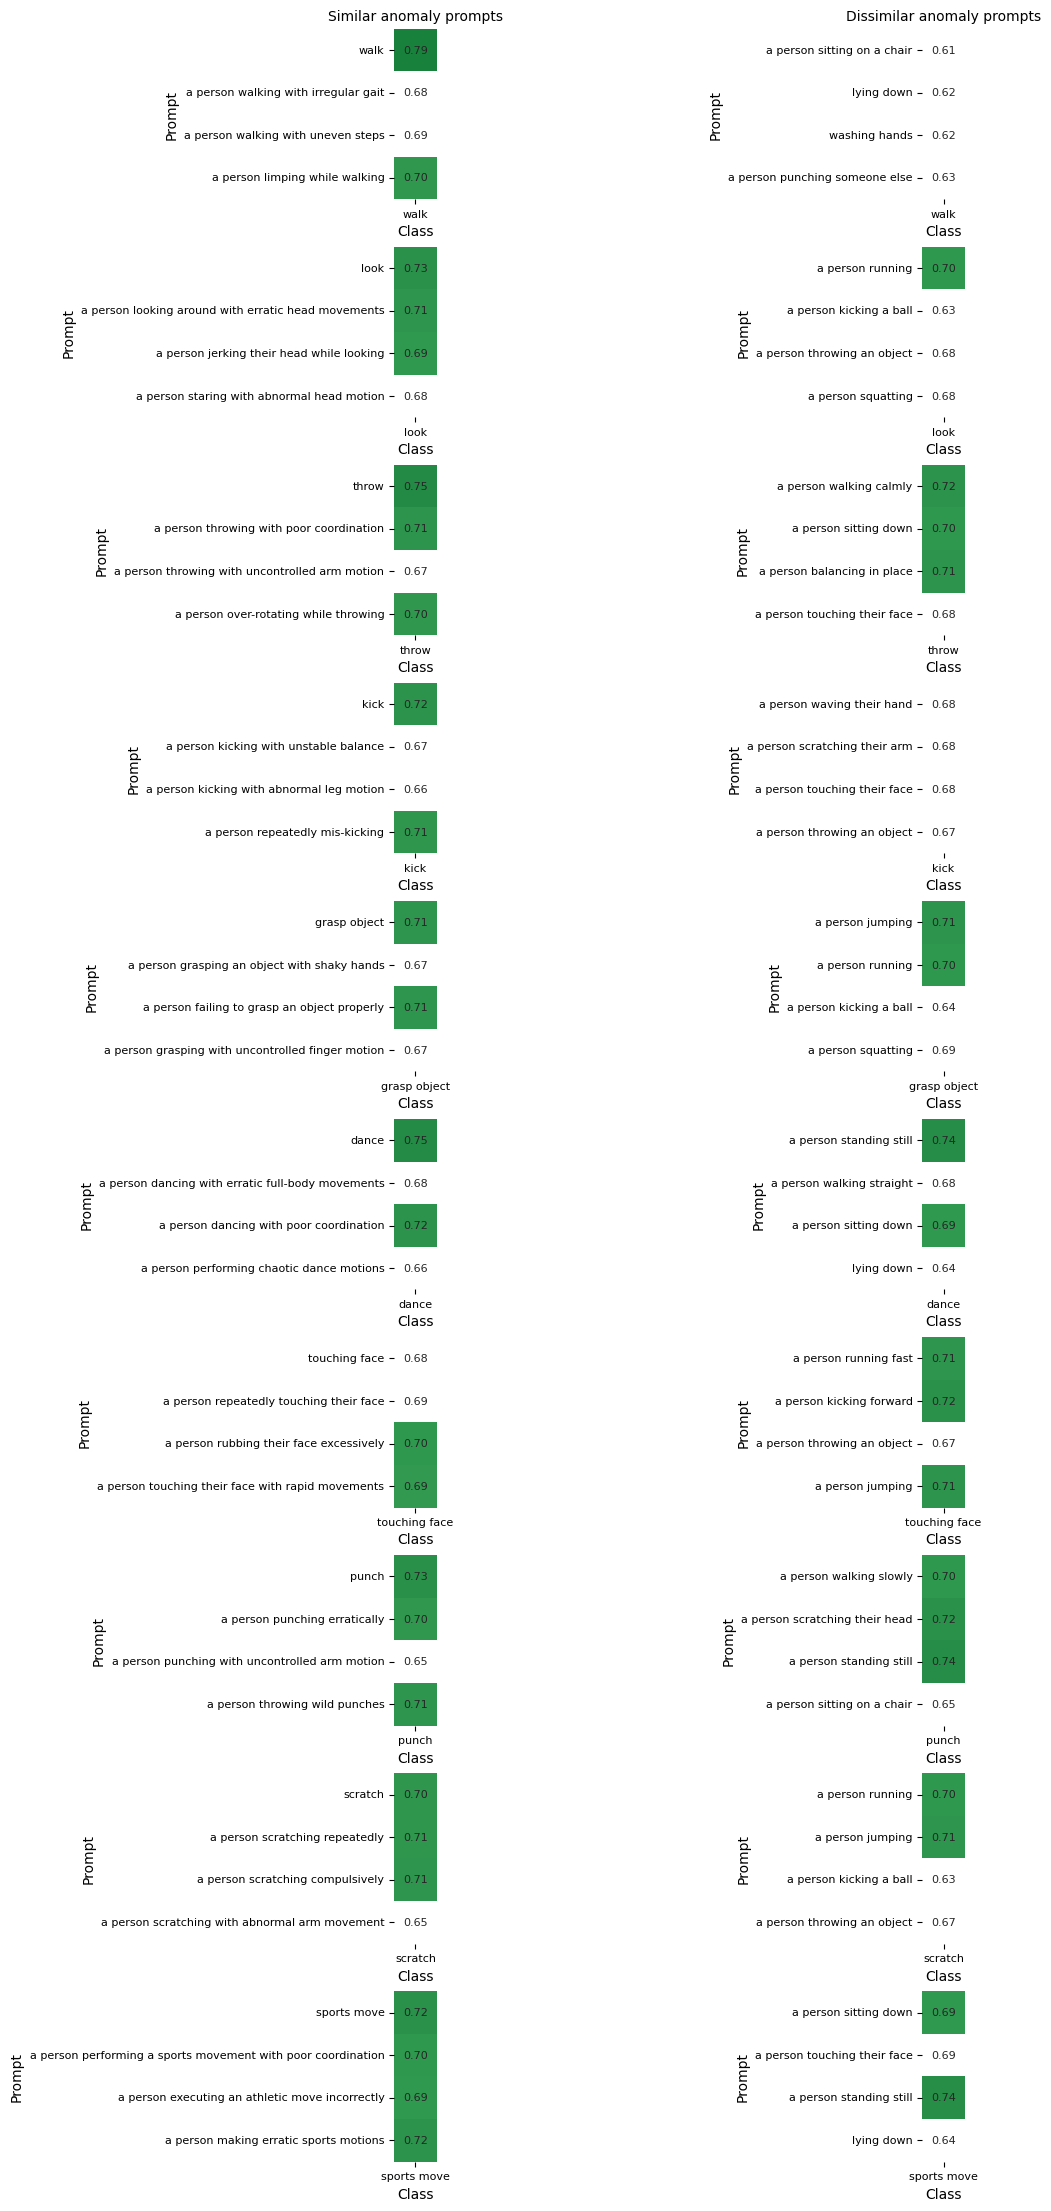

In [71]:
motions = list(motion_prompts.keys())
n_motions = len(motions)

fig, axes = plt.subplots(
    nrows=n_motions,
    ncols=2,
    figsize=(12, 2.2 * n_motions),
    sharex=False,
    sharey=False,
    constrained_layout=True
)

for i, motion in enumerate(motions):
    similar_prompts, dissimilar_prompts = motion_prompts[motion]
    class_id = action_label_to_idx[motion]

    # compute scores (your existing logic)
    sim_df, sim_flag_df = compute_prompt_scores(similar_prompts, class_id)
    dis_df, dis_flag_df = compute_prompt_scores(dissimilar_prompts, class_id)

    # left column: similar
    plot_single_axis_heatmap(
        axes[i, 0],
        sim_df,
        sim_flag_df
        # title=f"{motion} — similar"
    )

    # right column: dissimilar
    plot_single_axis_heatmap(
        axes[i, 1],
        dis_df,
        dis_flag_df
        # title=f"{motion} — dissimilar"
    )
    axes[i, 0].set_title("", fontsize=9, loc="left")
    axes[i, 1].set_title("", fontsize=9)

axes[0, 0].set_title("Similar anomaly prompts", fontsize=10)
axes[0, 1].set_title("Dissimilar anomaly prompts", fontsize=10)

plt.subplots_adjust(
    hspace=0.8,   # vertical spacing between motions
    wspace=0.4    # spacing between similar / dissimilar
)
plt.savefig("data/graphs_anomalyDetection/similar_dissimilar_manualChosenPrompts_heatmap")
plt.show()



### Using Farthest point sampling to pick the motions

In [88]:
# build class-level embeddings
class_embeddings = {}
for class_id in range(0,60):
    embs = get_embedding_by_label(class_id)
    if embs is None:
        continue

    embs_np = np.stack([e.detach().cpu().numpy() for e in embs])

    mean_emb = embs_np.mean(axis=tuple(range(embs_np.ndim - 1)))

    mean_emb = mean_emb / np.linalg.norm(mean_emb)

    class_embeddings[class_id] = mean_emb

In [90]:
def farthest_point_sampling(class_embeddings, k, seed=None):
    class_ids = list(class_embeddings.keys())
    X = np.stack([class_embeddings[c] for c in class_ids])
    D = cosine_distances(X, X)

    rng = np.random.default_rng(seed)
    selected = [rng.integers(len(class_ids))]

    while len(selected) < k:
        # distance to closest selected point
        min_dist = np.min(D[:, selected], axis=1)
        next_idx = np.argmax(min_dist)
        selected.append(next_idx)

    return [class_ids[i] for i in selected]

In [96]:
fps_chosen_labels = farthest_point_sampling(
    class_embeddings,
    k=10,
    seed=0  # change seed to try alternatives
)

fps_chosen_motion = [idx_to_action_label[i] for i in chosen_labels]
print(fps_chosen_motion)

['punch', 't pose', 'jog', 'sit', 'walk', 'run', 'stand', 'arm movements', 'move up/down incline', 'clean something']


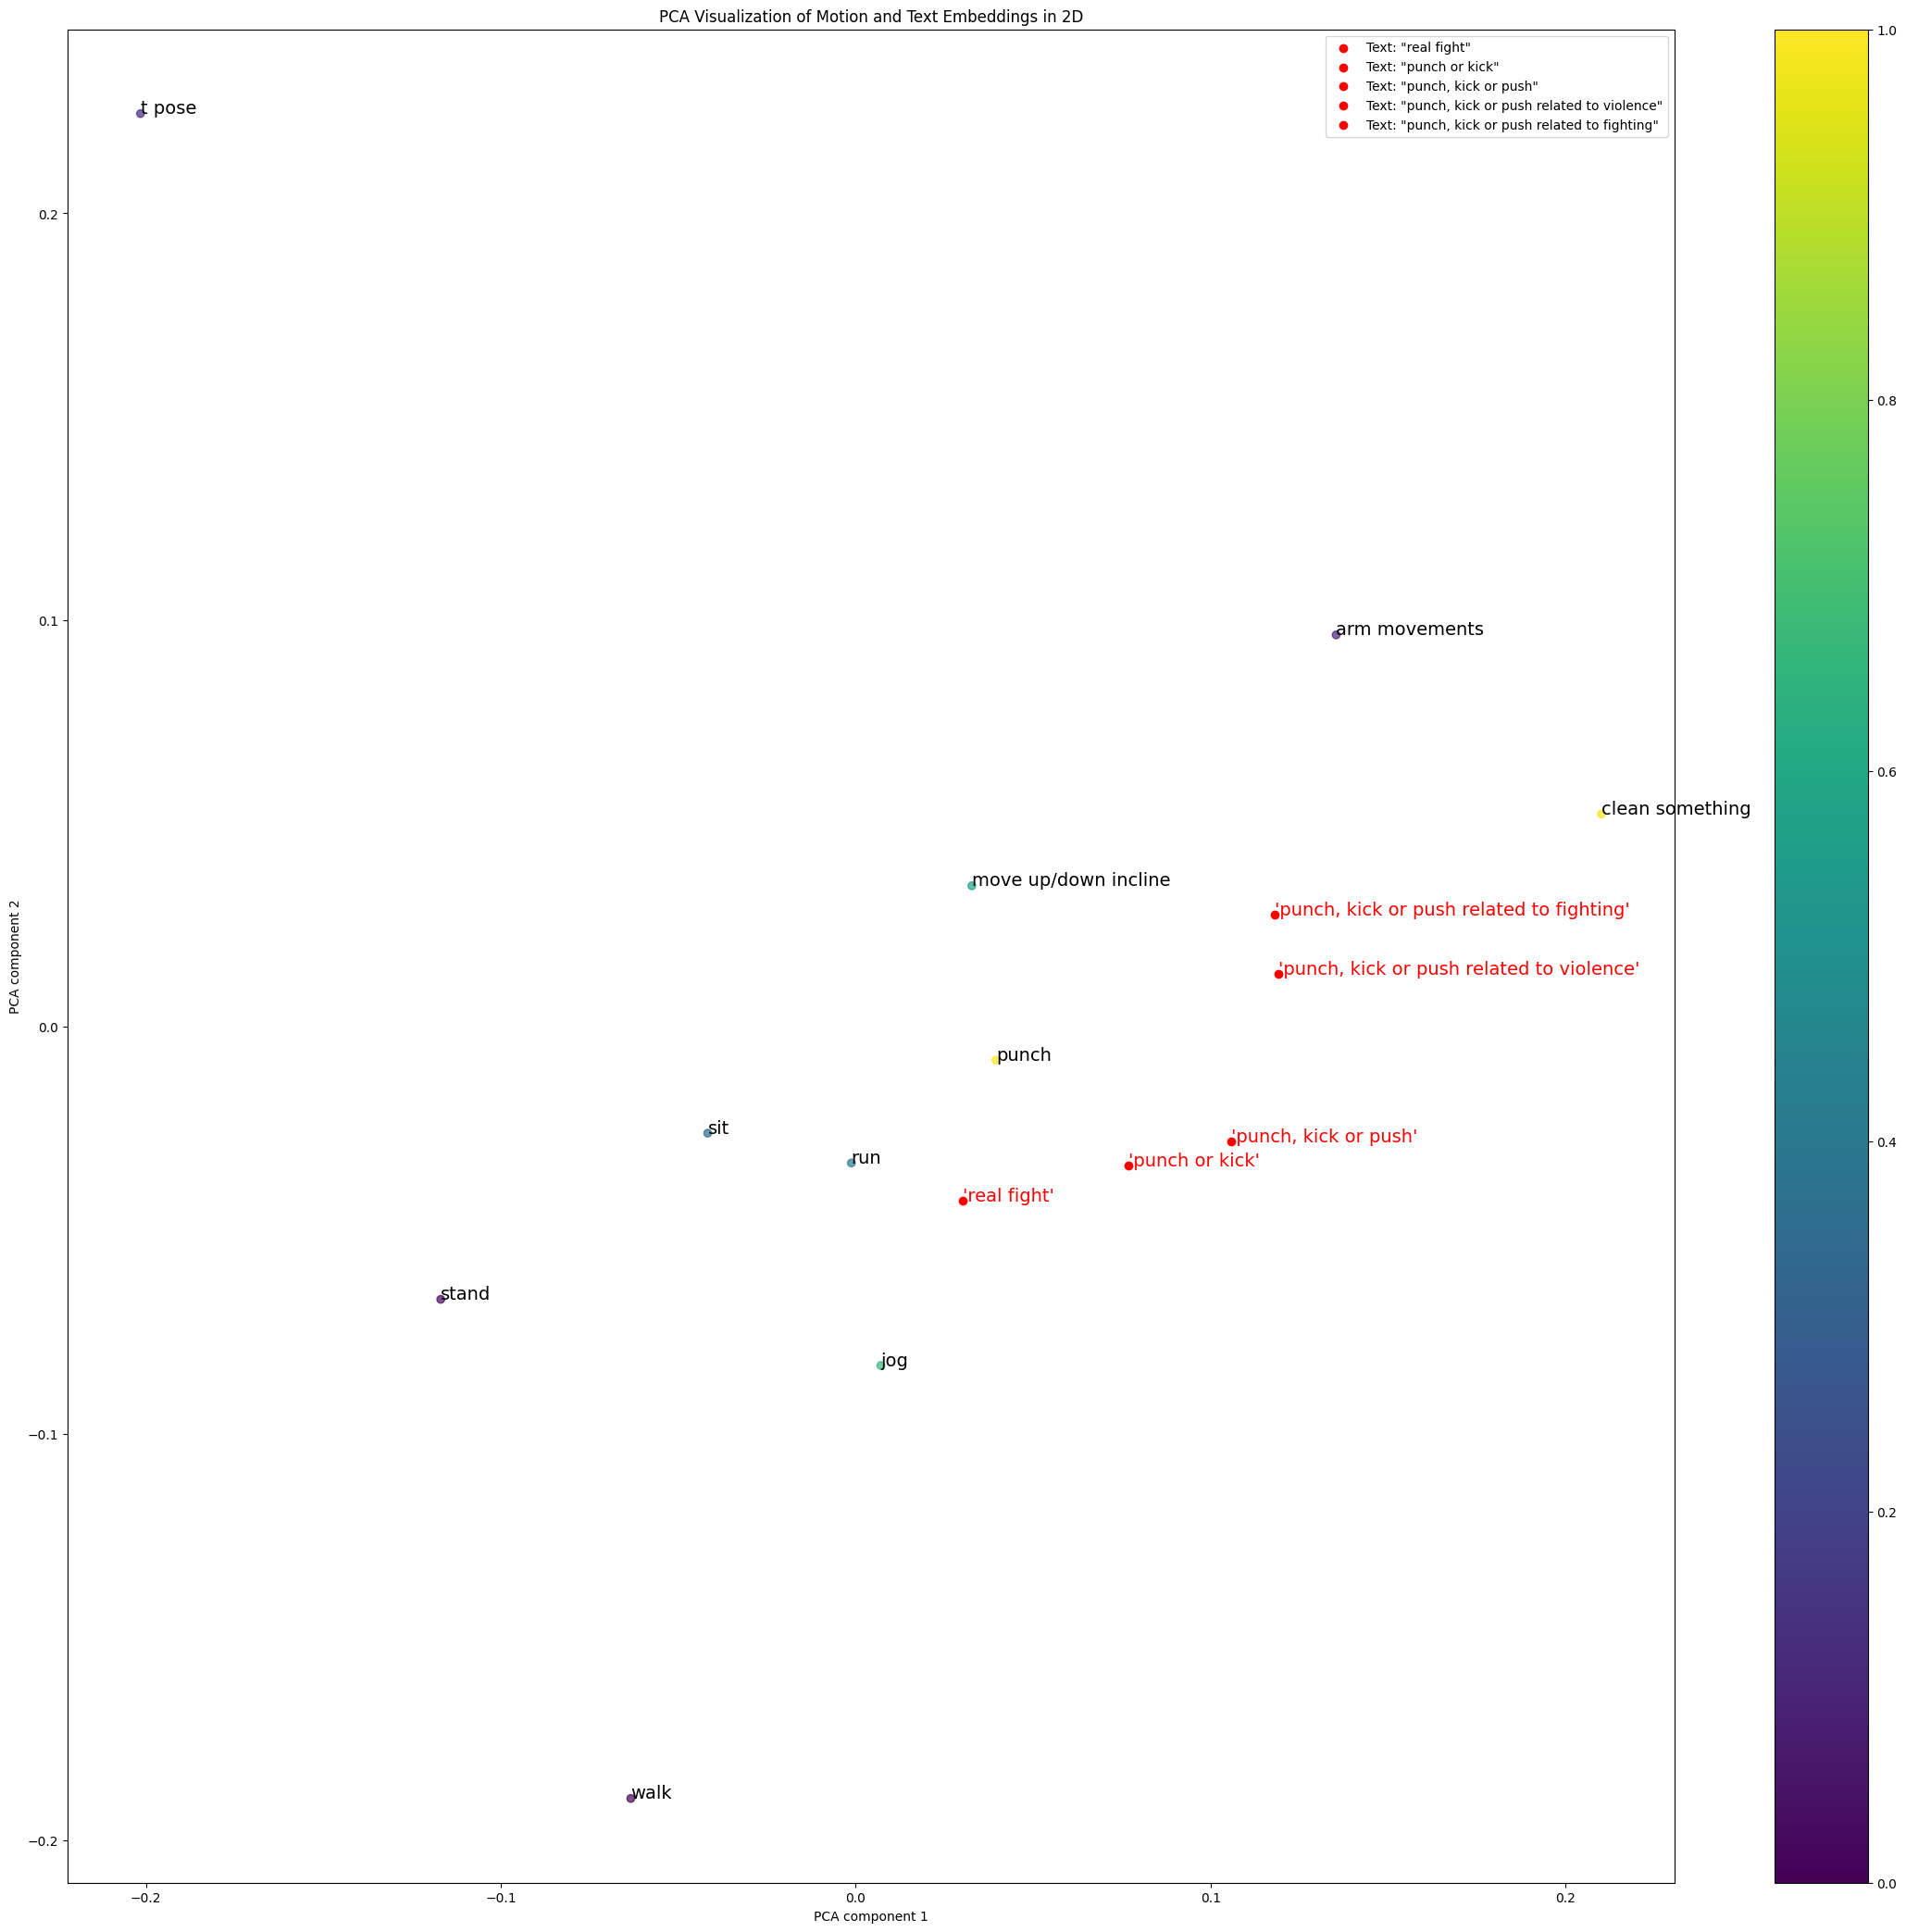

In [98]:
idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}

first_motion_embeddings = []
first_motion_labels = []

# unique_labels = np.unique(all_labels)
for label in fps_chosen_labels:
    first_index = np.where(np.array(all_labels) == label)[0][0]
    
    first_motion_embeddings.append(all_latents[first_index].cpu().detach().numpy())
    first_motion_labels.append(label)

first_motion_embeddings = np.vstack(first_motion_embeddings)

pca_motion = PCA(n_components=2) 
motion_embeddings_pca_2d = pca_motion.fit_transform(first_motion_embeddings)

text_embeddings_pca_2d = []
texts = []
texts_all = []
for prompt in anomaly_prompts:
    text_embedding, prompt = encode_text(prompt)

    text_embedding = text_embedding.cpu().detach().numpy().reshape(1, -1)  

    text_embedding_pca_2d = pca_motion.transform(text_embedding) 

    text_embeddings_pca_2d.append(text_embedding_pca_2d)
    texts.append(prompt)
plt.figure(figsize=(28, 26))

plt.scatter(motion_embeddings_pca_2d[:, 0], motion_embeddings_pca_2d[:, 1], c=first_motion_labels, cmap='viridis', alpha=0.7)

for i, text_embedding_pca in enumerate(text_embeddings_pca_2d):
    plt.scatter(text_embedding_pca[0, 0], text_embedding_pca[0, 1], c='red', label=f'Text: "{texts[i]}"')

    plt.text(text_embedding_pca[0, 0], text_embedding_pca[0, 1],
            f"'{texts[i]}'", fontsize=14, color='red')

for i, label in enumerate(first_motion_labels):
    action_label = idx_to_action_label[label] 
    plt.annotate(action_label, (motion_embeddings_pca_2d[i, 0], motion_embeddings_pca_2d[i, 1]), fontsize=14)

plt.colorbar()

plt.title("PCA Visualization of Motion and Text Embeddings in 2D")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")

plt.legend()
# plt.savefig("data/graphs_anomalyDetection/anomaly_paper_prompts")
plt.show()


In [99]:
motion_prompts_2 = {
    "punch": (
        [
            "punch",
            "a person punching erratically",
            "a person punching with uncontrolled arm motion",
            "a person throwing wild punches",
        ],
        [
            "a person sitting on a chair",
            "lying down",
            "a person standing still",
            "a person touching their face",
        ],
    ),

    "t pose": (
        [
            "t pose",
            "a person holding a t-pose with unstable arms",
            "a person struggling to maintain a t-pose",
            "a person standing in a distorted t-pose",
        ],
        [
            "a person walking forward",
            "a person running",
            "a person sitting down",
            "a person jumping",
        ],
    ),

    "jog": (
        [
            "jog",
            "a person jogging with irregular rhythm",
            "a person jogging with uneven steps",
            "a person jogging with poor coordination",
        ],
        [
            "a person standing still",
            "a person sitting on a chair",
            "a person touching their face",
            "a person cleaning an object",
        ],
    ),

    "sit": (
        [
            "sit",
            "a person sitting down awkwardly",
            "a person sitting with unstable posture",
            "a person repeatedly adjusting while sitting",
        ],
        [
            "a person running",
            "a person jumping",
            "a person kicking a ball",
            "a person punching someone",
        ],
    ),

    "walk": (
        [
            "walk",
            "a person walking with irregular gait",
            "a person walking with uneven steps",
            "a person limping while walking",
        ],
        [
            "a person sitting on a chair",
            "lying down",
            "washing hands",
            "a person punching someone else",
        ],
    ),

    "run": (
        [
            "run",
            "a person running with poor coordination",
            "a person running with unstable stride",
            "a person running erratically",
        ],
        [
            "a person sitting down",
            "a person standing still",
            "a person touching their face",
            "a person cleaning an object",
        ],
    ),

    "stand": (
        [
            "stand",
            "a person standing with unstable posture",
            "a person swaying while standing",
            "a person struggling to remain standing still",
        ],
        [
            "a person running",
            "a person jumping",
            "a person kicking a ball",
            "a person punching someone",
        ],
    ),

    "arm movements": (
        [
            "arm movements",
            "a person moving their arms erratically",
            "a person making uncontrolled arm motions",
            "a person swinging their arms abnormally",
        ],
        [
            "a person walking forward",
            "a person running",
            "a person sitting down",
            "a person standing still",
        ],
    ),

    "move up/down incline": (
        [
            "move up/down incline",
            "a person walking uphill with unstable steps",
            "a person moving down an incline awkwardly",
            "a person struggling while walking on a slope",
        ],
        [
            "a person sitting on a chair",
            "lying down",
            "a person standing still",
            "a person touching their face",
        ],
    ),

    "clean something": (
        [
            "clean something",
            "a person cleaning with repetitive motions",
            "a person cleaning an object erratically",
            "a person scrubbing with excessive movement",
        ],
        [
            "a person running",
            "a person jumping",
            "a person punching someone",
            "a person kicking a ball",
        ],
    ),
}


C:\Users\meenakshi\AppData\Local\Temp\ipykernel_24456\644663114.py:39: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(


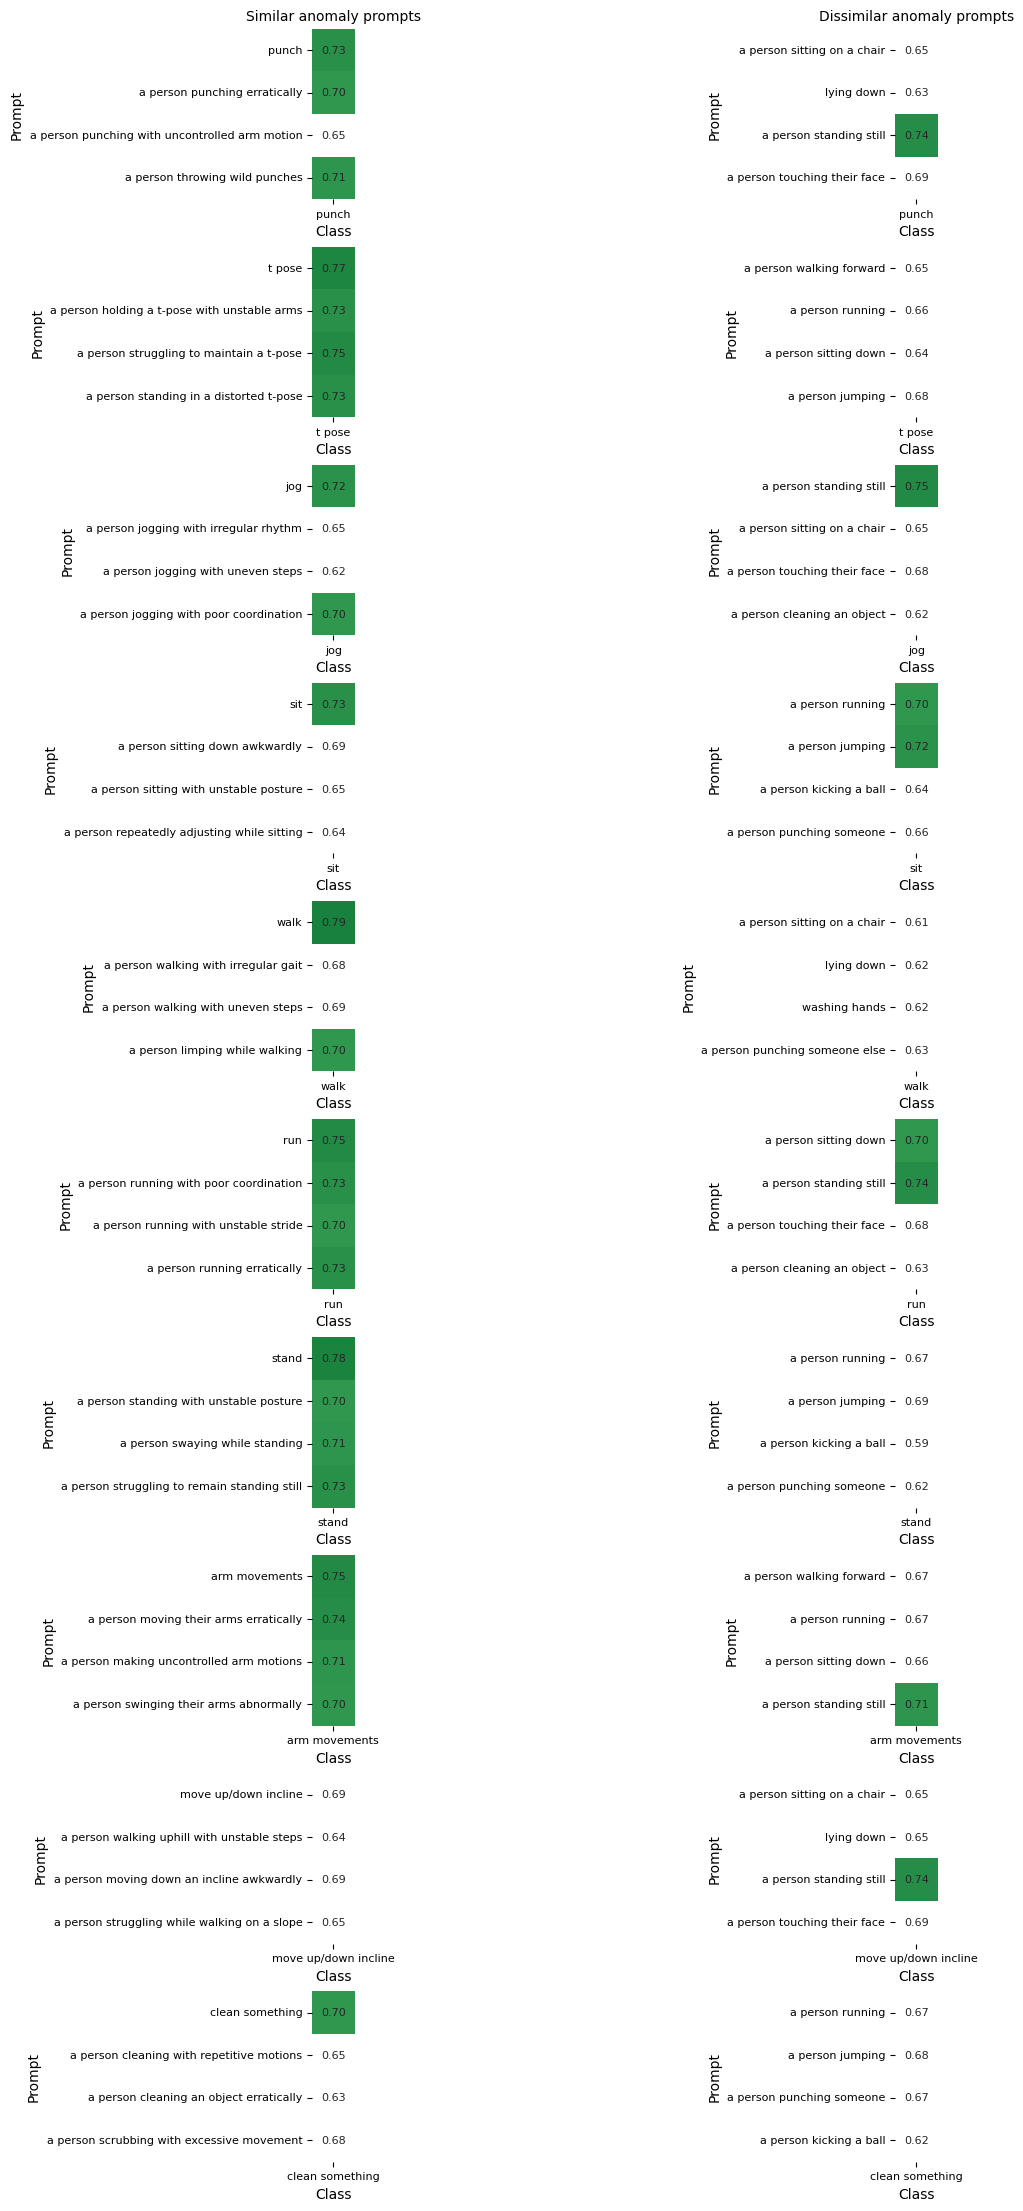

In [116]:
motions = list(motion_prompts_2.keys())
n_motions = len(motions)

fig, axes = plt.subplots(
    nrows=n_motions,
    ncols=2,
    figsize=(12, 2.2 * n_motions),
    sharex=False,
    sharey=False,
    constrained_layout=True
)

for i, motion in enumerate(motions):
    similar_prompts, dissimilar_prompts = motion_prompts_2[motion]
    class_id = action_label_to_idx[motion]

    sim_df, sim_flag_df = compute_prompt_scores(similar_prompts, class_id)
    dis_df, dis_flag_df = compute_prompt_scores(dissimilar_prompts, class_id)

    plot_single_axis_heatmap(
        axes[i, 0],
        sim_df,
        sim_flag_df
        # title=f"{motion} — similar"
    )

    plot_single_axis_heatmap(
        axes[i, 1],
        dis_df,
        dis_flag_df
        # title=f"{motion} — dissimilar"
    )
    axes[i, 0].set_title("", fontsize=9, loc="left")
    axes[i, 1].set_title("", fontsize=9)

axes[0, 0].set_title("Similar anomaly prompts", fontsize=10)
axes[0, 1].set_title("Dissimilar anomaly prompts", fontsize=10)

plt.subplots_adjust(
    hspace=0.8,   
    wspace=0.4    
)
# plt.savefig("data/graphs_anomalyDetection/similar_dissimilar_fpsChosenPrompts_heatmap")
plt.show()



### Additivity Test

In [104]:
additivity_tests = [
    ("walk", "trip", "fall"),
    ("jog", "speed up", "run"),
    ("walk", "speed up", "jog"),
    ("stand", "lose balance", "fall"),
    ("arm movements", "force", "punch"),
]

In [105]:
def get_motion_embedding(motion_name):
    class_id = action_label_to_idx[motion_name]
    return class_embeddings[class_id]

In [106]:
def get_text_embedding(text):
    e, _ = encode_text(text)
    e = e.cpu().detach().numpy().reshape(-1)
    return e / np.linalg.norm(e)

In [107]:
def test_additivity(base_motion, modifier, target_motion):
    # base motion embedding
    E_base = get_motion_embedding(base_motion)

    # modifier text embedding
    E_mod = get_text_embedding(modifier)

    # additive composition
    E_add = E_base + E_mod
    E_add = E_add / np.linalg.norm(E_add)

    # target motion embedding
    E_target = get_motion_embedding(target_motion)

    # similarity scores
    sim_target = cosine_similarity(
        E_add.reshape(1, -1),
        E_target.reshape(1, -1)
    )[0, 0]

    sim_base = cosine_similarity(
        E_add.reshape(1, -1),
        E_base.reshape(1, -1)
    )[0, 0]

    return sim_target, sim_base, E_add

In [108]:
additivity_results = {}

for base, modifier, target in additivity_tests:
    sim_target, sim_base, E_add = test_additivity(base, modifier, target)

    additivity_results[(base, modifier, target)] = {
        "sim_to_target": sim_target,
        "sim_to_base": sim_base,
    }

    print(f"{base} + {modifier} → {target}")
    print(f"  similarity to target: {sim_target:.3f}")
    print(f"  similarity to base  : {sim_base:.3f}")
    print()


KeyError: 'fall'